<a href="https://colab.research.google.com/github/sankajithdjinasena/Data_Visualization_Practical/blob/main/Data_Visualization_2026_06_15_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
diamonds = sns.load_dataset('diamonds')

In [14]:
agg_funcs = {
    'price': [
        ('Volume', 'count'),
        ('Median', 'median'),
        ('90th_Percentile', lambda x: x.quantile(0.90))
    ]
}

diamond_report = diamonds.groupby('clarity').agg(agg_funcs)

diamond_report.columns = diamond_report.columns.droplevel(0)
diamond_report = diamond_report.reset_index()

diamond_report = diamond_report.sort_values(by='Median').reset_index(drop=True)
diamond_report

/tmp/ipykernel_1685/3570301965.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diamond_report = diamonds.groupby('clarity').agg(agg_funcs)


,clarity,Volume,Median,90th_Percentile
0,IF,1790,1080.0,9662.3
1,VVS1,3655,1093.0,8162.4
2,VVS2,5066,1311.0,9625.5
3,VS1,8171,2005.0,9656.0
4,VS2,12258,2054.0,9580.3
5,SI1,13065,2822.0,9345.8
6,I1,741,3344.0,7197.0
7,SI2,9194,4072.0,12280.1


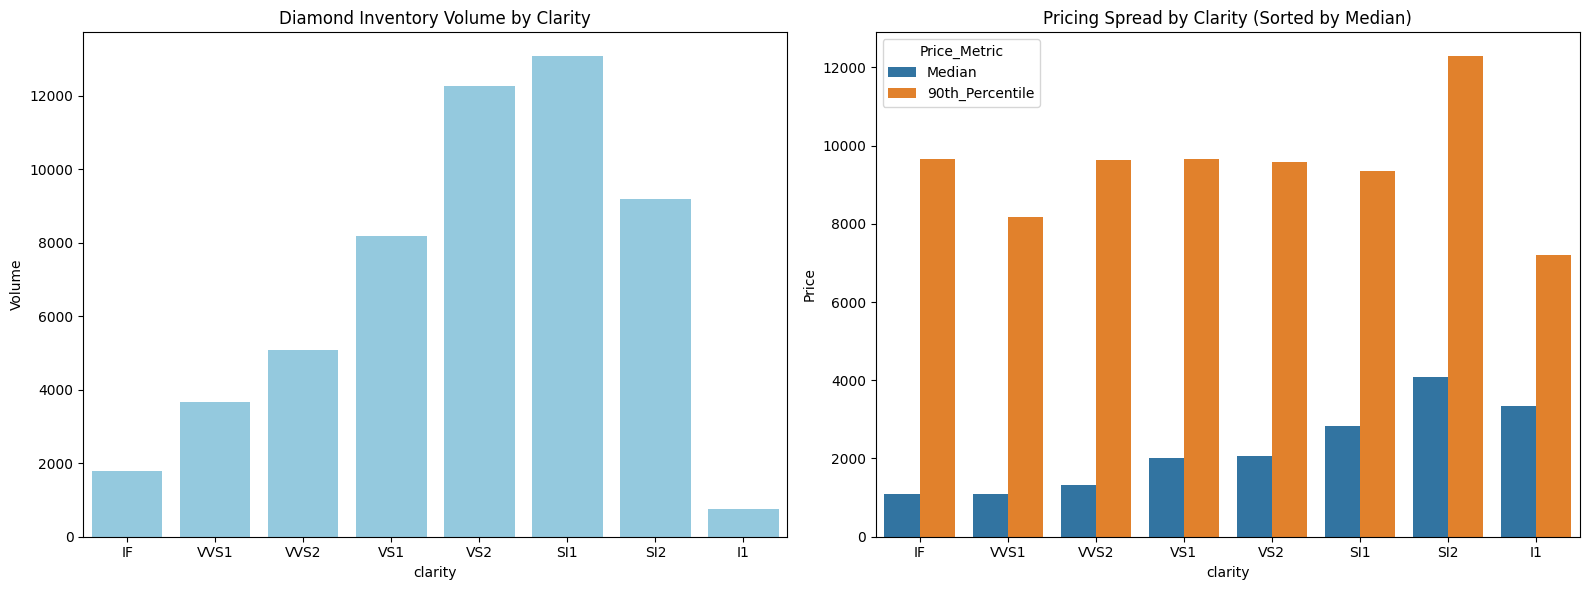

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=diamond_report, x='clarity', y='Volume', ax=axes[0], color='skyblue')
axes[0].set_title('Diamond Inventory Volume by Clarity')

# Melting the dataframe for easier grouped plotting in Seaborn
pricing_melted = diamond_report.melt(id_vars='clarity', value_vars=['Median', '90th_Percentile'],
                                     var_name='Price_Metric', value_name='Price')

sns.barplot(data=pricing_melted, x='clarity', y='Price', hue='Price_Metric', ax=axes[1])
axes[1].set_title('Pricing Spread by Clarity (Sorted by Median)')

plt.tight_layout()
plt.show()